# 사이클 단위 피처 31개 — 설명서

`Cycle_Feature_Extractor.py` 가 뽑는 피처를 **실제 데이터 예시와 함께** 정리한 문서.
셀을 위에서부터 실행하면 최근 24시간 P1 데이터로 모든 숫자와 그림이 다시 그려진다.

- 대상: 이 피처로 이상탐지 모델을 만들거나 결과를 해석하는 사람
- 짝 노트북: `Cycle_AE_v2.ipynb` (여기서 만든 피처로 오토인코더를 학습)

In [1]:
import os, sys
ROOT_DIR = os.path.dirname(os.getcwd())
sys.path.insert(0, ROOT_DIR); sys.path.insert(0, os.getcwd())

import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from Log_Extractor import LogExtractor
from Cycle_Feature_Extractor import (extract_cycle_features, PUMP_MAP,
                                     RAMP_THRESHOLD_PCT, DECAY_WINDOW_SEC, MIN_DECAY_POINTS,
                                     DIP_THRESHOLD_PCT, INJECTION_DIP_TICKS, STEADY_TICK_MIN)

PUMP_ID = "P1"
info = PUMP_MAP[PUMP_ID]
HEAD, ROBOT, SLOT = info["head"], info["robot"], info["slot"]

TAGS = [f"Pump_BuildUp_{PUMP_ID}", f"g_s_SV_{PUMP_ID}", f"Scale_Out___FT_{PUMP_ID}",
        f"Scale_Out___PT_{PUMP_ID}", f"Ana_Out_{PUMP_ID}", f"TK_Temp_PV_{PUMP_ID}",
        f"Hz_Out_{PUMP_ID}", f"Shot_Injection_{HEAD}_P{SLOT}", f"{ROBOT}_Robot_Num",
        "AL_Line_Bit"] + [f"{HEAD}_FOAMING_SHOT{k}" for k in range(1, 7)]

ex = LogExtractor(env_path=os.path.join(ROOT_DIR, ".env"))
raw = ex.get_data(start_time="-24h", end_time="now()", target_tags=TAGS)
cyc, _ = extract_cycle_features(raw, PUMP_ID)
print(f"\n사이클 {len(cyc):,}개 추출")

🔌 [Extractor] InfluxDB 분석용 추출기 연결 완료!
🚀 추출 시작: 2026-09-22T02:05:07.549841+00:00 ~ 2026-09-23T02:05:07.549861+00:00
   태그 16개 · 앞쪽 600초는 결측 복원용으로 더 받습니다
📦 [Chunk] 2026-09-22T01:55:07Z ~ 2026-09-22T07:55:07Z ... 

39360행
📦 [Chunk] 2026-09-22T07:55:07Z ~ 2026-09-22T13:55:07Z ... 

39280행
📦 [Chunk] 2026-09-22T13:55:07Z ~ 2026-09-22T19:55:07Z ... 

34154행
📦 [Chunk] 2026-09-22T19:55:07Z ~ 2026-09-23T01:55:07Z ... 

37584행
📦 [Chunk] 2026-09-23T01:55:07Z ~ 2026-09-23T02:05:07Z ... 

1037행


✅ 통합 완료 — 150365행 × 17컬럼
🌡️  온도 계열 컬럼 1개 — **단위가 태그마다 다르다.**
     TK_Temp_PV_P1            Scale_Max___TT_P1=1000 → 0.1℃ 단위, 값÷10
     ※ 2026-04 데이터는 Scale_Max___TT_P1=100 이었다. 지금은 1000 이라
       같은 태그가 22 → 228 로 찍힌다. 두 시기를 섞지 말 것.



사이클 3,174개 추출


---
## 0. 사이클이란 무엇인가

**1 사이클 = `Pump_BuildUp` 신호가 켜졌다 꺼지는 1회.** 기존 `train_pump.ipynb` 는
로봇 위치(`RB1_Robot_Num`)가 바뀔 때도 구간을 끊었지만, 실측해보니 로봇 위치 변경의
1~6% 가 **이미 가동 중인 사이클 한가운데**에서 일어나 사이클을 잘못 쪼갰다.
그래서 지금은 펌프 on/off 만으로 끊는다.

In [2]:
dur = (cyc["End_Time"] - cyc["Start_Time"]).dt.total_seconds()
print(f"사이클 길이   : 평균 {cyc['N_Ticks'].mean():.1f}틱 / {dur.mean():.1f}초")
print(f"               (중앙값 {cyc['N_Ticks'].median():.0f}틱 / {dur.median():.1f}초)")
print(f"하루 사이클 수 : 약 {len(cyc):,}회")
print()
print("참고 - '틱'은 균일한 시간 간격이 아니라 DB에 값이 기록된 한 줄이다.")
print("       (백엔드가 값이 바뀐 태그만 기록하므로 간격이 일정하지 않다)")

사이클 길이   : 평균 15.8틱 / 8.0초
               (중앙값 16틱 / 7.8초)
하루 사이클 수 : 약 3,174회

참고 - '틱'은 균일한 시간 간격이 아니라 DB에 값이 기록된 한 줄이다.
       (백엔드가 값이 바뀐 태그만 기록하므로 간격이 일정하지 않다)


### 한 사이클을 통째로 들여다보기

아래는 실제 사이클 하나의 원본 틱이다. 색칠한 구간이 각 피처가 계산되는 영역이다.

In [3]:
df = raw.ffill().fillna(0).reset_index()
df = df.rename(columns={df.columns[0]: "Time"})
bu = df[f"Pump_BuildUp_{PUMP_ID}"].astype(int)
df["Cycle_ID"] = (bu.diff().fillna(0) != 0).cumsum()

# 평범한 사이클 하나 고르기 (틱 수가 중앙값인 것)
med = int(cyc["N_Ticks"].median())
cand = cyc[(cyc["N_Ticks"] == med) & (~cyc["Excluded"])].index
cid = cand[len(cand) // 2]

seg = df[df["Cycle_ID"] == cid]
pre = df[df["Cycle_ID"] == cid - 1].tail(2)
post = df[df["Cycle_ID"] == cid + 1].head(6)
show = pd.concat([pre, seg, post])

cols = ["Time", f"Pump_BuildUp_{PUMP_ID}", f"g_s_SV_{PUMP_ID}", f"Scale_Out___FT_{PUMP_ID}",
        f"Scale_Out___PT_{PUMP_ID}", f"Hz_Out_{PUMP_ID}", f"Shot_Injection_{HEAD}_P{SLOT}"]
disp = show[cols].copy()
disp.columns = ["Time", "BuildUp", "SV", "FT", "PT", "Hz", "사출"]
print(f"=== Cycle {cid} ===")
print(disp.to_string(index=False))

=== Cycle 3027 ===
                      Time  BuildUp     SV     FT    PT     Hz  사출
2026-09-22 18:25:18.136456      0.0 2150.0 1285.0  63.0 2000.0 0.0
2026-09-22 18:25:18.664695      0.0 2150.0 1285.0  56.0 2000.0 0.0
2026-09-22 18:25:19.179630      1.0 2680.0 1285.0  71.0 4194.0 0.0
2026-09-22 18:25:19.702899      1.0 2680.0 1322.0 117.0 4194.0 0.0
2026-09-22 18:25:20.249771      1.0 2680.0 2293.0 122.0 4194.0 0.0
2026-09-22 18:25:20.761119      1.0 2680.0 2293.0 120.0 4194.0 0.0
2026-09-22 18:25:21.312716      1.0 2680.0 2644.0 120.0 4194.0 0.0
2026-09-22 18:25:21.820014      1.0 2680.0 2644.0 121.0 4194.0 0.0
2026-09-22 18:25:22.337747      1.0 2680.0 2644.0 123.0 4194.0 0.0
2026-09-22 18:25:22.859366      1.0 2680.0 2644.0 117.0 4194.0 1.0
2026-09-22 18:25:23.393965      1.0 2680.0 2658.0 113.0 4194.0 1.0
2026-09-22 18:25:23.900421      1.0 2680.0 2658.0 122.0 4194.0 0.0
2026-09-22 18:25:24.426936      1.0 2680.0 2644.0 121.0 4194.0 0.0
2026-09-22 18:25:24.953850      1.0 2680.0 

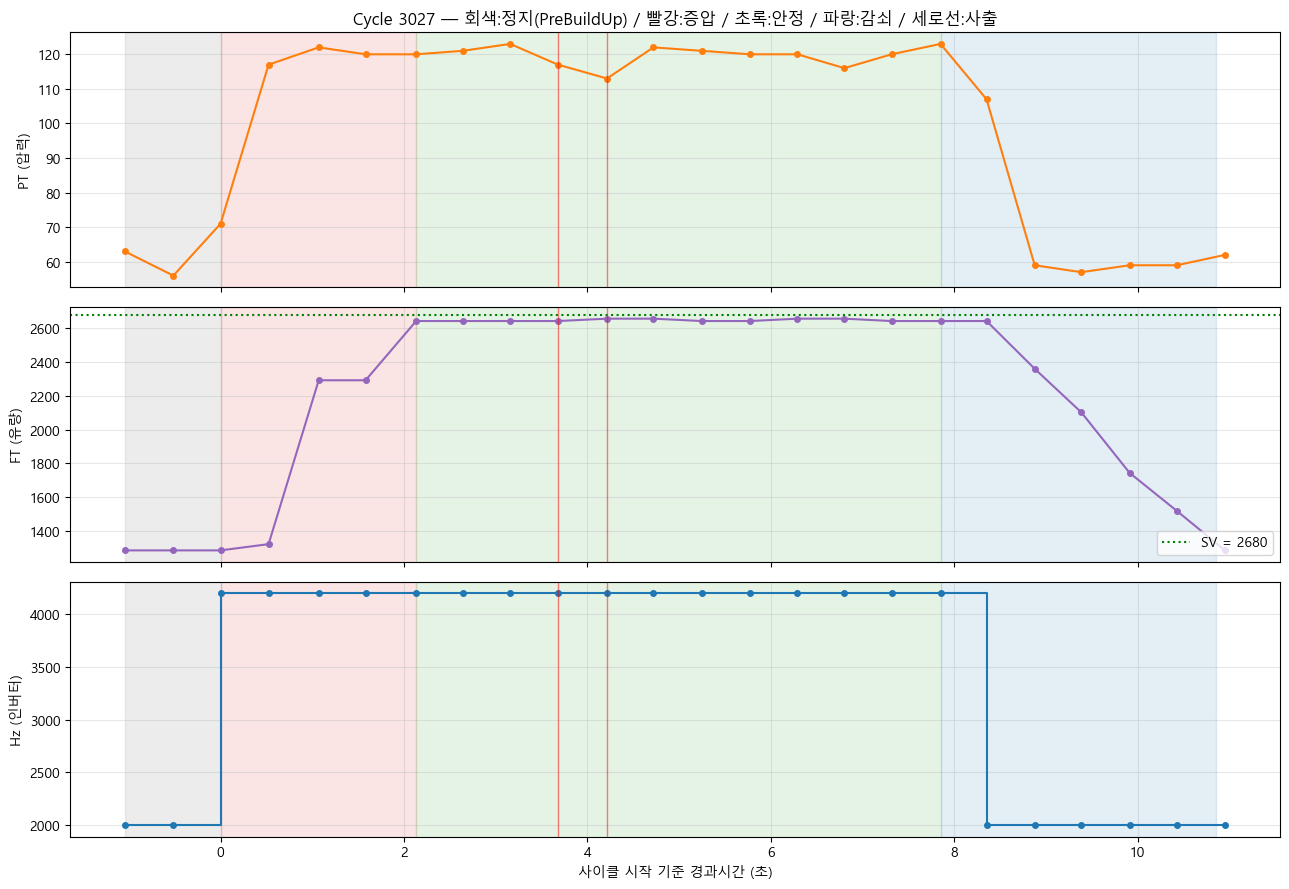

In [4]:
t0 = seg["Time"].iloc[0]
t_end = seg["Time"].iloc[-1]
x = (show["Time"] - t0).dt.total_seconds()

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
row = cyc.loc[cid]

axes[0].plot(x, show[f"Scale_Out___PT_{PUMP_ID}"], marker="o", ms=4, color="tab:orange")
axes[0].set_ylabel("PT (압력)")
axes[1].plot(x, show[f"Scale_Out___FT_{PUMP_ID}"], marker="o", ms=4, color="tab:purple")
axes[1].axhline(row["SV_mean"], ls=":", color="green", label=f"SV = {row['SV_mean']:.0f}")
axes[1].set_ylabel("FT (유량)"); axes[1].legend(loc="lower right")
axes[2].plot(x, show[f"Hz_Out_{PUMP_ID}"], marker="o", ms=4, color="tab:blue", drawstyle="steps-post")
axes[2].set_ylabel("Hz (인버터)"); axes[2].set_xlabel("사이클 시작 기준 경과시간 (초)")

ramp_end = row["RampUp_Time_Sec"]
decay_end = (t_end - t0).total_seconds() + DECAY_WINDOW_SEC
for ax in axes:
    ax.axvspan(x.min(), 0, color="gray", alpha=.15)
    ax.axvspan(0, ramp_end, color="tab:red", alpha=.12)
    ax.axvspan(ramp_end, (t_end - t0).total_seconds(), color="tab:green", alpha=.12)
    ax.axvspan((t_end - t0).total_seconds(), decay_end, color="tab:blue", alpha=.12)
    ax.grid(alpha=.3)
    inj_on = show[show[f"Shot_Injection_{HEAD}_P{SLOT}"] != 0]
    for tt in (inj_on["Time"] - t0).dt.total_seconds():
        ax.axvline(tt, color="red", lw=1, alpha=.5)

axes[0].set_title(f"Cycle {cid} — 회색:정지(PreBuildUp) / 빨강:증압 / 초록:안정 / 파랑:감쇠 / 세로선:사출")
plt.tight_layout(); plt.show()

---
## 1. 기본 통계 (10개) — 사이클 안의 값을 요약

가장 단순한 묶음. 사이클 안에 흩어져 있는 틱들의 평균/최대/표준편차를 낸 것이다.
기존 방식은 이 값들을 **틱마다 따로** 모델에 넣었는데, 그러면 "설정값이 바뀐 순간"이
매번 이상으로 잡힌다. 사이클 단위로 요약하면 그 문제가 사라진다.

| 피처 | 의미 |
|---|---|
| `N_Ticks` | 이 사이클이 몇 틱이었나. 평소보다 길거나 짧으면 뭔가 다른 것 |
| `SV_mean` | 목표 유량 설정값 (레시피마다 다름) |
| `FT_mean` / `FT_max` / `FT_std` | 실제 유량의 평균 / 최대 / 흔들림 |
| `PT_mean` / `PT_max` / `PT_std` | 실제 압력의 평균 / 최대 / 흔들림 |
| `Ana_Out_mean` | 펌프로 나가는 아날로그 제어 출력 |
| `Temp_mean` | 탱크 온도 (값÷10 이 실제 ℃) |

In [5]:
base = ["N_Ticks","SV_mean","FT_mean","FT_max","FT_std","PT_mean","PT_max","PT_std","Ana_Out_mean","Temp_mean"]
print(f"=== Cycle {cid} 의 값 vs 전체 분포 ===")
tbl = pd.DataFrame({
    "이 사이클": cyc.loc[cid, base],
    "전체 평균": cyc[base].mean(),
    "전체 표준편차": cyc[base].std(),
}).round(2)
print(tbl.to_string())

=== Cycle 3027 의 값 vs 전체 분포 ===
                 이 사이클    전체 평균  전체 표준편차
N_Ticks          16.00    15.76     1.94
SV_mean        2680.00  2358.08   274.99
FT_mean        2436.06  2174.56   220.57
FT_max         2658.00  2354.69   264.86
FT_std          458.25   353.64   101.29
PT_mean         116.62   102.45    12.28
PT_max          123.00   108.59    12.85
PT_std           12.46     8.06     3.70
Ana_Out_mean  11184.00  9831.65  1149.04
Temp_mean       222.00   218.65    10.90


---
## 2. 직전 상태와의 비교 (6개) — "평소와 달라졌나"

절대값만 보면 레시피가 바뀔 때마다 이상으로 보인다. **직전 사이클, 직전 정지 상태와
비교**해야 진짜 변화를 잡을 수 있다.

| 피처 | 계산 | 왜 필요한가 |
|---|---|---|
| `Prev_SV` | 직전 사이클의 SV 최댓값 | 레시피가 바뀌었는지 판단 기준 |
| `Prev_SV_Diff` | 현재 SV − Prev_SV | 0이면 같은 레시피 연속, 크면 제품 전환 |
| `PreBuildUp_PT` | **켜지기 직전** 정지 상태의 압력 | 시작 전 배관에 압력이 남아있었나 |
| `PreBuildUp_FT` | 같은 시점의 유량 | 시작 전 유량 상태 |
| `PT_Jump_From_Pre` | 사이클 첫 틱 PT − PreBuildUp_PT | 켜자마자 압력이 얼마나 튀었나 |
| `FT_Jump_From_Pre` | 사이클 첫 틱 FT − PreBuildUp_FT | 켜자마자 유량이 얼마나 튀었나 |

`PreBuildUp_*` 은 **정지 구간(BuildUp=0)의 값**이다. 기존 방식은 정지 구간을 통째로
버려서 이 피처를 아예 만들 수 없었다.

In [6]:
prev_cols = ["Prev_SV","Prev_SV_Diff","PreBuildUp_PT","PreBuildUp_FT","PT_Jump_From_Pre","FT_Jump_From_Pre"]
print(f"=== Cycle {cid} ===")
for c in prev_cols:
    print(f"  {c:20s} {cyc.loc[cid, c]:10.1f}")
print()
print("직전 정지 구간의 마지막 2틱 (PreBuildUp 값이 여기서 나옴):")
print(pre[["Time", f"Scale_Out___PT_{PUMP_ID}", f"Scale_Out___FT_{PUMP_ID}"]].to_string(index=False))
print()
print(f"사이클 첫 틱: PT={seg[f'Scale_Out___PT_{PUMP_ID}'].iloc[0]:.0f}, FT={seg[f'Scale_Out___FT_{PUMP_ID}'].iloc[0]:.0f}")
print(f"  → PT_Jump = {cyc.loc[cid,'PT_Jump_From_Pre']:.0f},  FT_Jump = {cyc.loc[cid,'FT_Jump_From_Pre']:.0f}")

=== Cycle 3027 ===
  Prev_SV                  2150.0
  Prev_SV_Diff              530.0
  PreBuildUp_PT              56.0
  PreBuildUp_FT            1285.0
  PT_Jump_From_Pre           15.0
  FT_Jump_From_Pre            0.0

직전 정지 구간의 마지막 2틱 (PreBuildUp 값이 여기서 나옴):
                      Time  Scale_Out___PT_P1  Scale_Out___FT_P1
2026-09-22 18:25:18.136456               63.0             1285.0
2026-09-22 18:25:18.664695               56.0             1285.0

사이클 첫 틱: PT=71, FT=1285
  → PT_Jump = 15,  FT_Jump = 0


---
## 3. 목표 대비 오차 (3개) — "지시한 만큼 나왔나"

| 피처 | 계산 |
|---|---|
| `Instant_FT_Error_Rate_mean` | 사이클 내내 `(SV−FT)/SV×100` 의 평균 |
| `Instant_FT_Error_Rate_max` | 그 절댓값의 최대 (보통 증압 초반 첫 틱) |
| `Cum_FT_Error` | `(SV−FT)` 를 사이클 내내 누적한 값 |

`_mean` 이 크다는 건 사이클 내내 목표에 못 미쳤다는 뜻이고, `_max` 는 보통 증압 초반
(아직 목표에 도달 전)이라 정상 사이클에서도 크게 나온다. 둘을 같이 봐야 구분된다.

In [7]:
err_cols = ["Instant_FT_Error_Rate_mean","Instant_FT_Error_Rate_max","Cum_FT_Error"]
print(f"=== Cycle {cid} ===")
for c in err_cols:
    print(f"  {c:30s} {cyc.loc[cid,c]:10.2f}   (전체 평균 {cyc[c].mean():8.2f})")

sv = seg[f"g_s_SV_{PUMP_ID}"].values; ft = seg[f"Scale_Out___FT_{PUMP_ID}"].values
rate = np.where(sv > 0, (sv - ft) / sv * 100, 0)
print()
print("틱별 오차율(%):", np.round(rate, 1))

=== Cycle 3027 ===
  Instant_FT_Error_Rate_mean           9.10   (전체 평균     7.61)
  Instant_FT_Error_Rate_max           52.05   (전체 평균    44.33)
  Cum_FT_Error                      3903.00   (전체 평균  2869.39)

틱별 오차율(%): [52.1 50.7 14.4 14.4  1.3  1.3  1.3  1.3  0.8  0.8  1.3  1.3  0.8  0.8
  1.3  1.3]


---
## 4. 물리 지표 (7개) — 여기가 핵심

설비의 물리적 상태를 직접 겨냥한 피처들. 기존 14개에는 하나도 없던 것들이고,
실제로 이상탐지에서 가장 많이 범인으로 지목되는 피처들이다.

### 4-1. `RampUp_Time_Sec` — 증압이 얼마나 빨리 되나

펌프를 켜고 나서 유량이 목표치 근처(`|FT−SV|/SV ≤ 5%`)에 **처음 도달할 때까지 걸린 초**.

틱 개수가 아니라 **실제 타임스탬프 차이**를 쓴다 — 틱 간격이 균일하지 않기 때문이다.

느려지면: 펌프 토출 능력 저하, 필터 막힘, 누설

In [8]:
sv_ref = seg[f"g_s_SV_{PUMP_ID}"].iloc[0]
ok = np.abs(sv - ft) / sv_ref <= RAMP_THRESHOLD_PCT
et = (seg["Time"] - t0).dt.total_seconds().values
print(f"SV = {sv_ref:.0f},  허용범위 ±{RAMP_THRESHOLD_PCT*100:.0f}% = {sv_ref*(1-RAMP_THRESHOLD_PCT):.0f} ~ {sv_ref*(1+RAMP_THRESHOLD_PCT):.0f}")
print()
for i in range(min(8, len(seg))):
    mark = "  ← 목표 진입" if ok[i] and not ok[:i].any() else ""
    print(f"  틱{i}  t={et[i]:5.2f}초  FT={ft[i]:7.0f}  {'O' if ok[i] else 'X'}{mark}")
print(f"\n→ RampUp_Time_Sec = {cyc.loc[cid,'RampUp_Time_Sec']:.3f}초  (전체 평균 {cyc['RampUp_Time_Sec'].mean():.3f}초)")

SV = 2680,  허용범위 ±5% = 2546 ~ 2814

  틱0  t= 0.00초  FT=   1285  X
  틱1  t= 0.52초  FT=   1322  X
  틱2  t= 1.07초  FT=   2293  X
  틱3  t= 1.58초  FT=   2293  X
  틱4  t= 2.13초  FT=   2644  O  ← 목표 진입
  틱5  t= 2.64초  FT=   2644  O
  틱6  t= 3.16초  FT=   2644  O
  틱7  t= 3.68초  FT=   2644  O

→ RampUp_Time_Sec = 2.133초  (전체 평균 1.734초)


### 4-2. `DeltaP_over_Q` — 유로 저항

안정구간의 **평균 PT ÷ 평균 FT**. 노즐 같은 좁은 구멍은 `Δp ∝ Q²` 관계라, 이 비율은
"같은 유량을 내보내는 데 압력을 얼마나 썼는가" = 저항의 지표가 된다.

- 비율이 **오르면** → 같은 유량에 더 센 압력 필요 → **막힘**
- 비율이 **떨어지면** → 적은 압력으로 유량이 나옴 → **마모/내부 바이패스**

정상 상태에서 매우 안정적이라(변동계수 3% 수준) 작은 변화도 눈에 띈다.

### 4-3. `Current_Proxy_I` — 전류(부하) 추정치

$$I = K \cdot \frac{\Delta p \cdot \dot m}{f}$$

안정구간에서 `PT × FT ÷ Hz_Out` 의 평균. 비례상수 `K`(효율)는 알 수 없으므로 생략하고
**상대적 추세**로 쓴다.

유압동력(Δp×Q)을 회전속도로 나누면 토크가 되고, 인버터 구동 모터에서 토크는 전류에
거의 비례한다. 이 설비엔 전류계가 없어서 압력·유량·주파수만으로 부하를 역산하는 것이다.
극수(pole) 를 몰라도 되도록 주파수를 그대로 쓴다.

In [9]:
phys = ["RampUp_Time_Sec","DeltaP_over_Q","Current_Proxy_I"]
print(f"{'피처':22s} {'이 사이클':>10s} {'평균':>10s} {'표준편차':>10s} {'변동계수':>8s}")
for c in phys:
    m, s = cyc[c].mean(), cyc[c].std()
    print(f"{c:22s} {cyc.loc[cid,c]:10.4f} {m:10.4f} {s:10.4f} {s/abs(m)*100:7.1f}%")

피처                          이 사이클         평균       표준편차     변동계수
RampUp_Time_Sec            2.1331     1.7344     0.3525    20.3%
DeltaP_over_Q              0.0463     0.0456     0.0015     3.4%
Current_Proxy_I           74.2265    64.6730     7.6073    11.8%


### 4-4. `Decay_Slope_PT` / `Decay_Slope_FT` — 끄고 나서 빠지는 속도

`Pump_BuildUp` 이 꺼진 직후 **3초 창**에서 PT(그리고 FT)를 시간에 대해 1차 회귀한 기울기.
단위는 초당 변화량이고, 정상이면 음수(떨어짐)다.

**최소 3개 포인트**가 있어야 계산한다. 실측상 창 안에 4~5개가 들어오는 경우가 98.5%이고,
2개뿐인 경우(0.1%)는 두 값이 우연히 같으면 기울기가 정확히 0으로 나와 가짜 이상을 만들어서
버린다.

평소보다 **빨리 빠지면** 밸브가 안 닫히거나 씰이 새는 신호일 수 있다.

감쇠 창 = 사이클 종료(18:25:27) 이후 3초, 최소 3점 필요
이 사이클은 5개 포인트

  t=+0.50초   PT=   107   FT=   2644
  t=+1.03초   PT=    59   FT=   2361
  t=+1.54초   PT=    57   FT=   2103
  t=+2.06초   PT=    59   FT=   1744
  t=+2.58초   PT=    59   FT=   1519

→ Decay_Slope_PT =   -18.54 /초  (전체 평균   -11.01)
→ Decay_Slope_FT =  -553.00 /초  (전체 평균  -521.82)


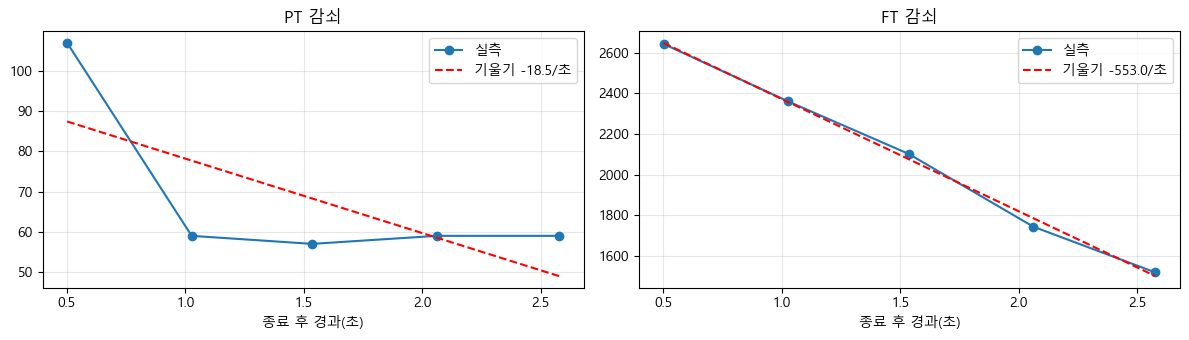

In [10]:
off = df[bu == 0].sort_values("Time")
w = off[(off["Time"] > t_end) & (off["Time"] <= t_end + pd.Timedelta(seconds=DECAY_WINDOW_SEC))]
tt = (w["Time"] - t_end).dt.total_seconds().values
print(f"감쇠 창 = 사이클 종료({t_end.strftime('%H:%M:%S')}) 이후 {DECAY_WINDOW_SEC:.0f}초, 최소 {MIN_DECAY_POINTS}점 필요")
print(f"이 사이클은 {len(w)}개 포인트\n")
for i in range(len(w)):
    print(f"  t=+{tt[i]:.2f}초   PT={w[f'Scale_Out___PT_{PUMP_ID}'].iloc[i]:6.0f}   FT={w[f'Scale_Out___FT_{PUMP_ID}'].iloc[i]:7.0f}")
print(f"\n→ Decay_Slope_PT = {cyc.loc[cid,'Decay_Slope_PT']:8.2f} /초  (전체 평균 {cyc['Decay_Slope_PT'].mean():8.2f})")
print(f"→ Decay_Slope_FT = {cyc.loc[cid,'Decay_Slope_FT']:8.2f} /초  (전체 평균 {cyc['Decay_Slope_FT'].mean():8.2f})")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
for a, (col, name) in zip(ax, [(f"Scale_Out___PT_{PUMP_ID}", "PT"), (f"Scale_Out___FT_{PUMP_ID}", "FT")]):
    y = w[col].values
    a.plot(tt, y, "o-", label="실측")
    if len(tt) >= 2:
        sl, ic = np.polyfit(tt, y, 1)
        a.plot(tt, sl * tt + ic, "--", color="red", label=f"기울기 {sl:.1f}/초")
    a.set_title(f"{name} 감쇠"); a.set_xlabel("종료 후 경과(초)"); a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 4-5. `Steady_Std_PT` / `Steady_Std_FT` — 기저 변동성

안정구간(사이클 시작 후 3틱 이후)에서 PT/FT의 표준편차. **명령이 그대로인데 값이 떨리는
정도**를 본다.

커지면: 컴펜세이터 헌팅, 릴리프밸브 채터링, 캐비테이션

---
## 5. 이벤트 카운트 (5개) — "있으면 안 될 일이 몇 번 있었나"

앞의 피처들이 "평균적으로 어떤가"를 본다면, 이건 **사이클 안에서 특정 사건이 몇 번
일어났는지** 세는 것이다. 정상 사이클에서는 대부분 0이다.

### 5-1. `Ramp_Negative_Slope_Count` — 증압 중에 거꾸로 간 횟수

증압 구간에서 유량은 목표를 향해 **올라가기만 해야 한다.** 틱 간 변화량이 음수인 틱의
개수를 센다.

베어링 파손처럼 순간적으로 일어나는 고장은 이런 급격한 단차로 나타난다.

### 5-2. `Unexplained_PT_Dip_Count` / `_Max` — 설명 안 되는 압력 하락 ★

**이 피처가 가장 중요하다.** 원리는 이렇다:

- 사출(`Shot_Injection_HD1_P1`)할 때 압력이 떨어지는 건 **정상**이다 (액을 뽑아내니까)
- 사출이 없는데 압력이 떨어지면 → **어딘가로 새고 있다는 뜻**

실측으로 확인한 사출 시 압력 거동 (P1 사출 3,265건 평균):

| 사출 시작 기준 | PT 변화 | FT 변화 |
|---|---|---|
| −1틱 | 기준 | 기준 |
| **0틱 (사출 시작)** | **−3.5** | **+111** |
| +1틱 | **−9.4 (최저)** | +143 |
| +2틱 | −6.2 | +150 |
| +3틱 | −0.8 | +145 |
| +4틱 | −0.2 (회복) | +134 |

사출 신호 자체는 평균 2.4틱만 켜지는데 딥은 +3틱까지 이어진다. 그래서 **사출 시작 후
4틱까지를 "설명된 구간"** 으로 넓혀 잡는다. 그렇게 안 하면 회복 중 하락이 유출로
잘못 잡힌다.

판정 조건 (셋 다 만족해야 카운트):
1. 안정구간일 것 (시작 후 3틱 이후)
2. 직전 3틱 평균 대비 **3% 이상** 하락
3. 그 시점이 이 펌프의 사출 구간(+4틱)이 **아닐 것**

`_Count` 는 그런 틱이 몇 개였는지, `_Max` 는 그 중 최대 하락률.

> **주의**: FT는 사출 때 **올라간다**. 그래서 `Unexplained_FT_Dip` 은 "사출로 설명된다"는
> 논리가 애초에 성립하지 않고, 사실상 "유량이 갑자기 떨어진 적이 있나"를 세는 피처다.

In [11]:
ev = ["Ramp_Negative_Slope_Count","Unexplained_PT_Dip_Count","Unexplained_PT_Dip_Max",
      "Unexplained_FT_Dip_Count","Unexplained_FT_Dip_Max"]
print(f"{'피처':30s} {'이 사이클':>10s} {'평균':>9s} {'0 아닌 비율':>12s} {'최대':>8s}")
for c in ev:
    print(f"{c:30s} {cyc.loc[cid,c]:10.3f} {cyc[c].mean():9.3f} "
          f"{(cyc[c]>0).mean()*100:11.1f}% {cyc[c].max():8.2f}")

피처                                  이 사이클        평균      0 아닌 비율       최대
Ramp_Negative_Slope_Count           0.000     0.170        13.1%     2.00
Unexplained_PT_Dip_Count            1.000     0.453        38.8%     4.00
Unexplained_PT_Dip_Max              0.036     0.015        38.8%     0.07
Unexplained_FT_Dip_Count            0.000     0.005         0.5%     1.00
Unexplained_FT_Dip_Max              0.000     0.000         0.5%     0.08


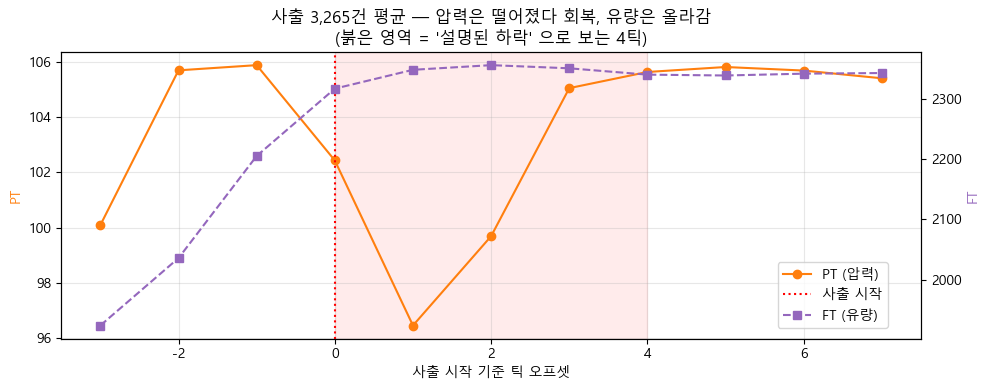

In [12]:
# 사출 시점 정렬 평균 곡선 — 위 표의 근거
inj = (df[f"Shot_Injection_{HEAD}_P{SLOT}"] != 0).values
pt_all = df[f"Scale_Out___PT_{PUMP_ID}"].values
ft_all = df[f"Scale_Out___FT_{PUMP_ID}"].values
starts = np.where(inj & ~np.r_[False, inj[:-1]])[0]

offs = range(-3, 8)
pt_prof = [pt_all[np.clip(starts + o, 0, len(pt_all)-1)].mean() for o in offs]
ft_prof = [ft_all[np.clip(starts + o, 0, len(ft_all)-1)].mean() for o in offs]

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(list(offs), pt_prof, "o-", color="tab:orange", label="PT (압력)")
ax1.set_ylabel("PT", color="tab:orange"); ax1.set_xlabel("사출 시작 기준 틱 오프셋")
ax2 = ax1.twinx()
ax2.plot(list(offs), ft_prof, "s--", color="tab:purple", label="FT (유량)")
ax2.set_ylabel("FT", color="tab:purple")
ax1.axvline(0, color="red", ls=":", label="사출 시작")
ax1.axvspan(0, INJECTION_DIP_TICKS, color="red", alpha=.08)
ax1.set_title(f"사출 {len(starts):,}건 평균 — 압력은 떨어졌다 회복, 유량은 올라감\n"
              f"(붉은 영역 = '설명된 하락' 으로 보는 {INJECTION_DIP_TICKS}틱)")
ax1.grid(alpha=.3)
fig.legend(loc="lower right", bbox_to_anchor=(0.9, 0.15))
plt.tight_layout(); plt.show()

---
## 6. 전체 피처 분포 한눈에 보기

In [13]:
FEATURE_COLS = ["N_Ticks","SV_mean","FT_mean","FT_max","FT_std","PT_mean","PT_max","PT_std",
    "Ana_Out_mean","Temp_mean","Prev_SV","Prev_SV_Diff","PreBuildUp_PT","PreBuildUp_FT",
    "PT_Jump_From_Pre","FT_Jump_From_Pre","Instant_FT_Error_Rate_mean","Instant_FT_Error_Rate_max",
    "Cum_FT_Error","RampUp_Time_Sec","DeltaP_over_Q","Current_Proxy_I","Steady_Std_PT","Steady_Std_FT",
    "Ramp_Negative_Slope_Count","Unexplained_PT_Dip_Count","Unexplained_PT_Dip_Max",
    "Unexplained_FT_Dip_Count","Unexplained_FT_Dip_Max","Decay_Slope_PT","Decay_Slope_FT"]

summary = pd.DataFrame({
    "평균": cyc[FEATURE_COLS].mean(),
    "표준편차": cyc[FEATURE_COLS].std(),
    "최소": cyc[FEATURE_COLS].min(),
    "중앙값": cyc[FEATURE_COLS].median(),
    "최대": cyc[FEATURE_COLS].max(),
    f"Cycle {cid}": cyc.loc[cid, FEATURE_COLS],
}).round(3)
print(f"피처 {len(FEATURE_COLS)}개")
print(summary.to_string())

피처 31개
                                  평균      표준편차        최소       중앙값         최대  Cycle 3027
N_Ticks                       15.759     1.942     8.000    16.000     24.000      16.000
SV_mean                     2358.080   274.991  2010.000  2350.000   2980.000    2680.000
FT_mean                     2174.564   220.567  1847.500  2157.606   2665.000    2436.062
FT_max                      2354.691   264.864  2001.000  2337.000   2950.000    2658.000
FT_std                       353.638   101.292   142.611   334.123    729.992     458.253
PT_mean                      102.450    12.275    82.571   100.258    142.000     116.625
PT_max                       108.587    12.855    88.000   106.000    151.000     123.000
PT_std                         8.063     3.702     1.889     7.385     22.966      12.463
Ana_Out_mean                9831.653  1149.040  8367.000  9783.000  12514.000   11184.000
Temp_mean                    218.651    10.903   187.812   218.935    240.000     222.000
Pre

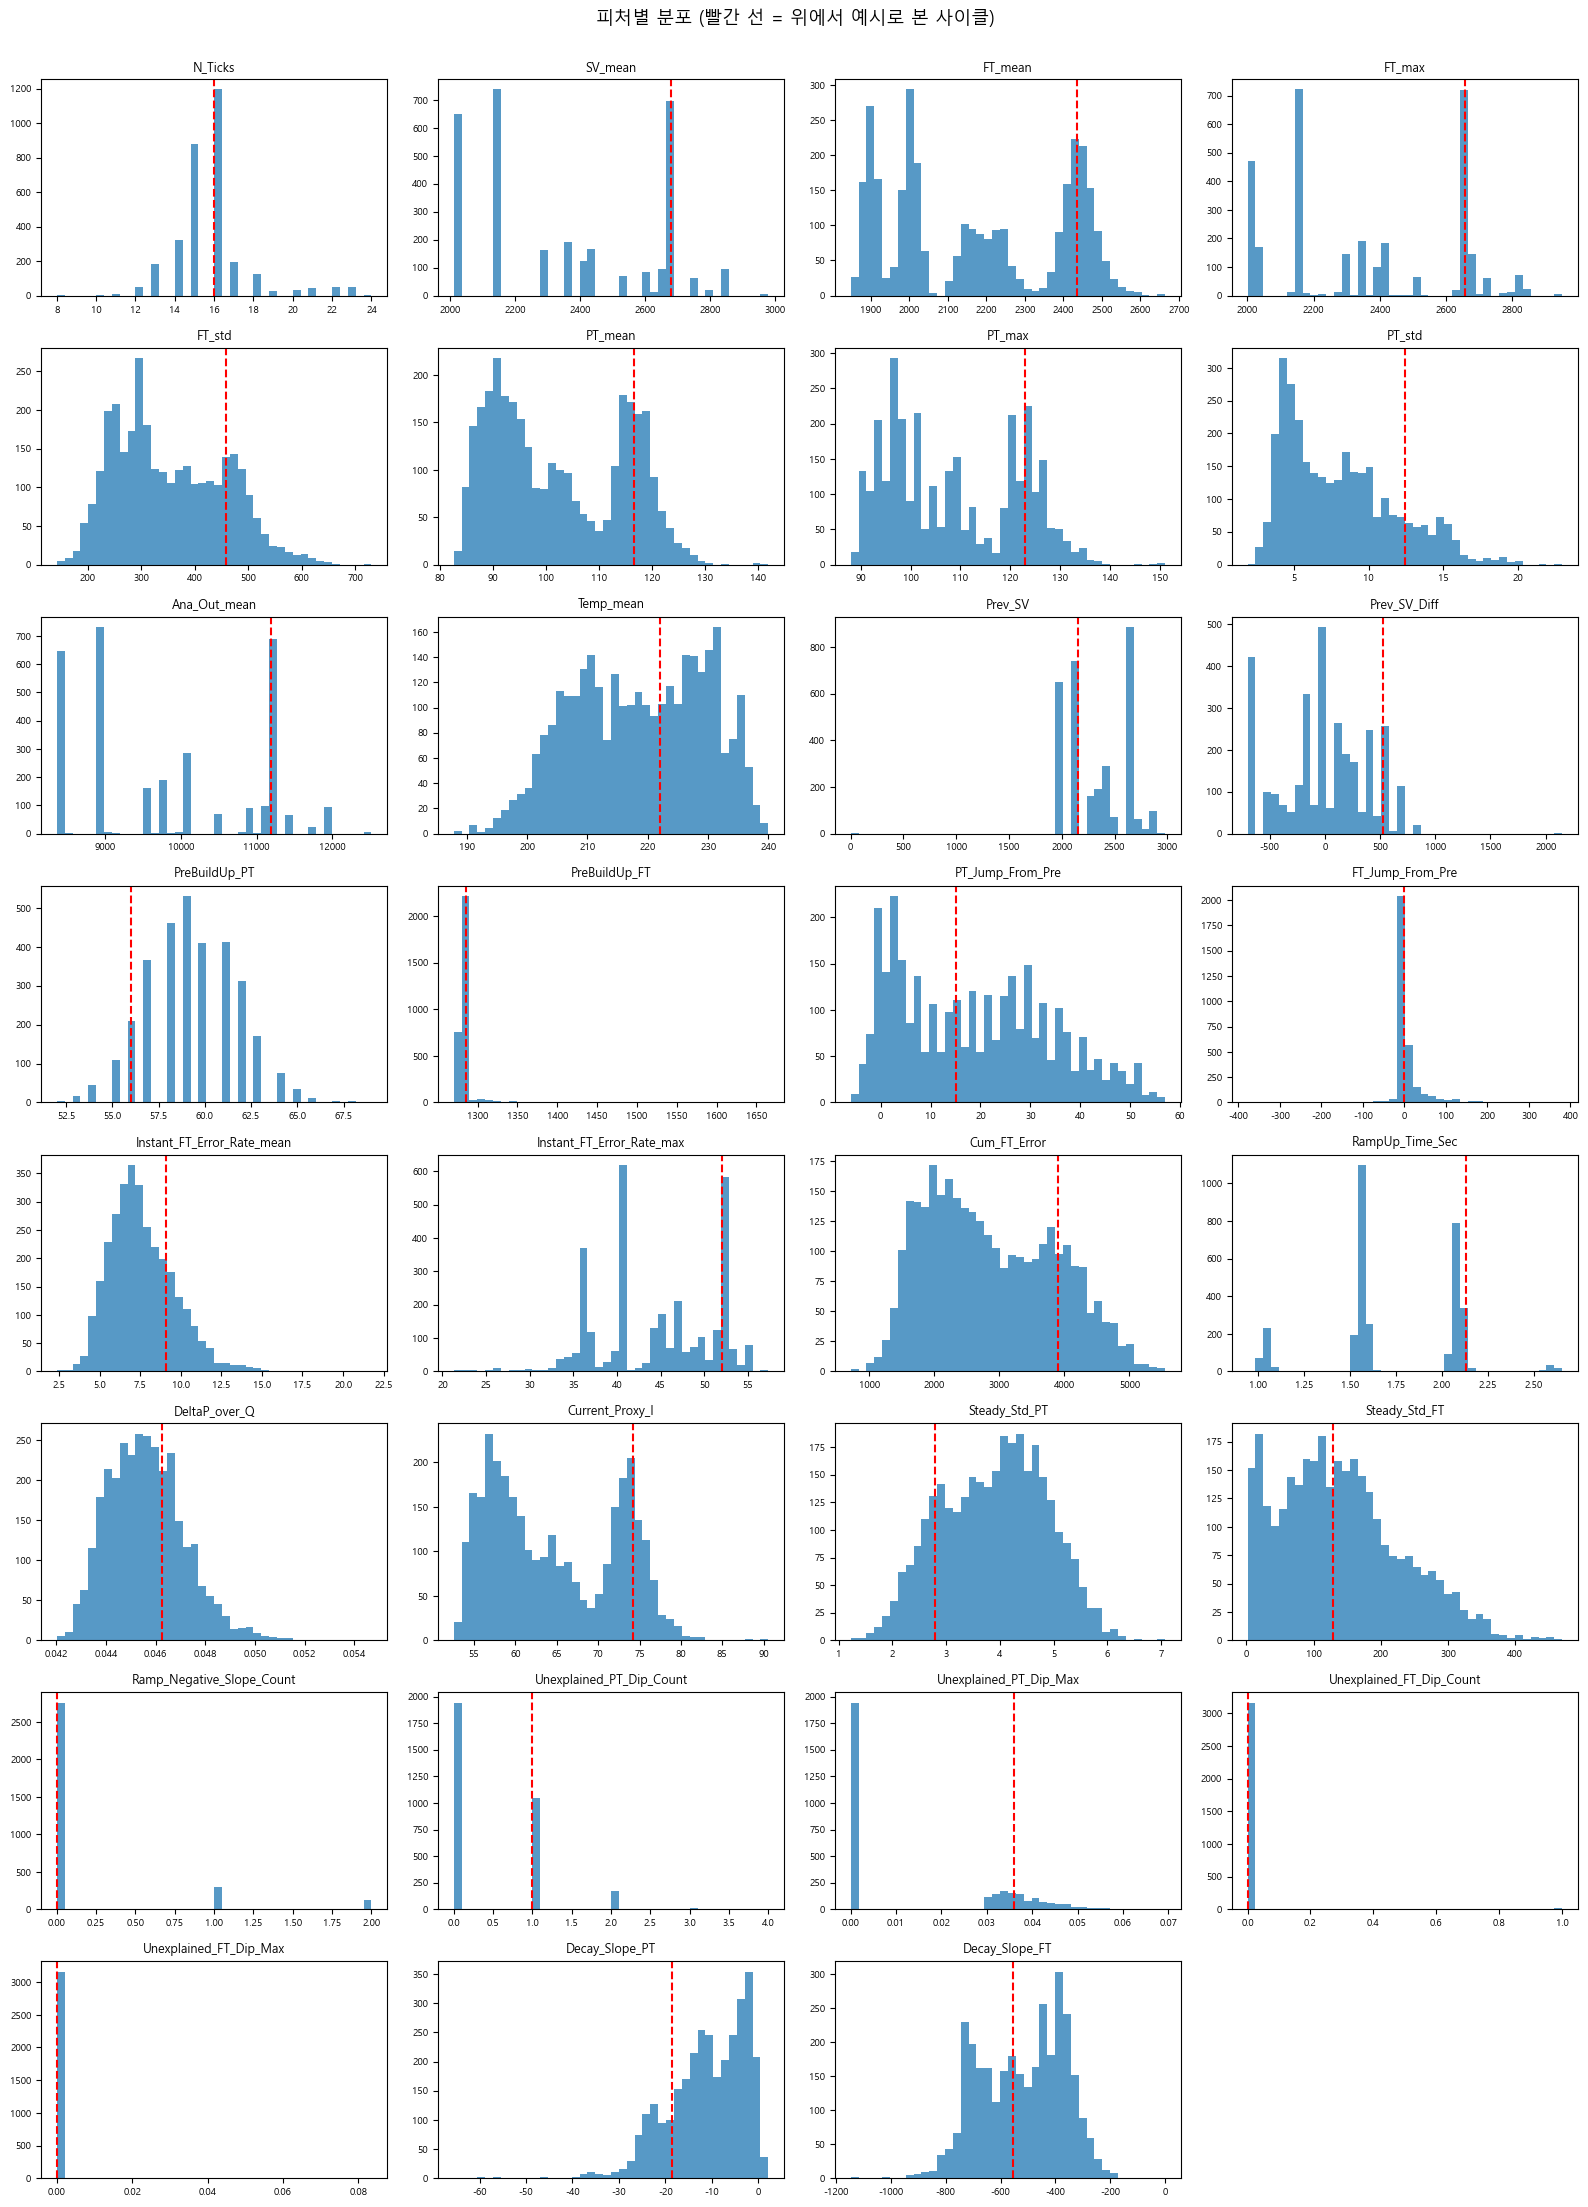

In [14]:
fig, axes = plt.subplots(8, 4, figsize=(16, 22))
for ax, c in zip(axes.ravel(), FEATURE_COLS):
    ax.hist(cyc[c].dropna(), bins=40, color="tab:blue", alpha=.75)
    ax.axvline(cyc.loc[cid, c], color="red", ls="--", lw=1.5)
    ax.set_title(c, fontsize=9)
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(FEATURE_COLS):]:
    ax.axis("off")
fig.suptitle("피처별 분포 (빨간 선 = 위에서 예시로 본 사이클)", y=1.001, fontsize=13)
plt.tight_layout(); plt.show()

---
## 7. 제외 규칙

모든 사이클을 쓰는 게 아니라, 아래에 해당하면 학습에서 뺀다.

| 규칙 | 이유 |
|---|---|
| 매일 **23:50~07:00** 에 시작한 사이클 | 야간에 토출이 불안정. 06:45 로 잡았을 때 06시대 이상률이 7.77% (다른 시간대 1~2.8%) 로 튀어서 07:00 까지 넓혔다 |
| `AL_Line_Bit == 1` | 라인 알람이 떠 있던 구간 (참고: 최근 데이터엔 발생 0건) |
| `Prev_SV == 0` | 추출 구간의 첫 사이클. 직전 사이클이 없어 비교 피처가 무의미 |
| 감쇠 포인트 3개 미만 | 기울기를 신뢰할 수 없음 |

In [15]:
print(f"전체 {len(cyc):,} 사이클 중")
print(f"  야간(23:50~07:00) 시작 : {int(cyc['Excluded_DailyWindow'].sum()):5d}")
print(f"  AL_Line_Bit=1         : {int(cyc['Excluded_Alarm'].sum()):5d}")
print(f"  Prev_SV==0            : {int((cyc['Prev_SV']==0).sum()):5d}")
print(f"  감쇠 계산 불가(NaN)    : {int(cyc['Decay_Slope_PT'].isna().sum()):5d}")
print(f"  → 학습에 쓰는 사이클   : {len(cyc[~cyc['Excluded']].dropna(subset=FEATURE_COLS)):5d}")

전체 3,174 사이클 중
  야간(23:50~07:00) 시작 :    57
  AL_Line_Bit=1         :     0
  Prev_SV==0            :     1
  감쇠 계산 불가(NaN)    :     2
  → 학습에 쓰는 사이클   :  3115


---
# 8. 정규화 — 시작 조건의 영향을 걷어내기

여기까지의 피처는 전부 **원시값**이다. 그런데 일부 피처는 그 사이클이 어떤 상태에서
시작했느냐에 크게 끌려다녀서, 그대로 쓰면 "설비가 이상한 것"과 "시작 조건이 달랐던 것"을
구분할 수 없다.

## 8-1. 문제 확인

`Decay_Slope_PT`(펌프를 끈 뒤 압력이 빠지는 기울기)를 예로 본다.

In [ ]:
import numpy as np
from Cycle_Normalizer import ResidualNormalizer, NORMALIZE_SPECS, SUFFIX

sub = cyc.dropna(subset=["Decay_Slope_PT", "PT_at_End"])
print(f"Decay_Slope_PT 와 감쇠 시작 압력(PT_at_End) 의 상관 : "
      f"{sub['Decay_Slope_PT'].corr(sub['PT_at_End']):+.3f}\n")

b = pd.qcut(sub["PT_at_End"], 5, duplicates="drop")
g = sub.groupby(b).agg(건수=("PT_at_End", "size"),
                       시작압력=("PT_at_End", "mean"),
                       평균기울기=("Decay_Slope_PT", "mean")).round(2)
print("시작압력이 높을수록 가파르게 빠지는 것이 '정상' 이다:")
print(g.to_string())

위 표가 보여주듯 **압력이 높으면 3배 가파르게 빠지는 게 정상**이다. 그래서 원시 기울기만으로는

- 기울기 −7 이 나왔을 때 → 시작 압력이 낮아서 그런 건지, 아니면 막혀서 안 빠진 건지
- 기울기 −30 이 나왔을 때 → 시작 압력이 높아서 그런 건지, 아니면 새고 있는 건지

를 구분할 수 없다.

## 8-2. 두 단계 보정

**1단계 (위치)** — 정상 데이터로 `예상값 = a × 기준변수 + b` 를 적합하고, 실제와의 차이(잔차)를 쓴다.

**2단계 (폭)** — 흩어진 정도도 기준변수를 따라가므로, 잔차를 그 구간의 예상 흩어짐으로 나눈다.

```
피처 = (실제값 − 예상값) ÷ 예상흩어짐
```

2단계가 필요한 이유는 아래에서 확인한다.

In [ ]:
train_mask = pd.to_datetime(cyc["Start_Time"]) < pd.Timestamp("2026-09-18 16:00")
train_part = cyc[train_mask].dropna(subset=["Decay_Slope_PT", "PT_at_End"])

a, b_ = np.polyfit(train_part["PT_at_End"], train_part["Decay_Slope_PT"], 1)
resid = sub["Decay_Slope_PT"] - (a * sub["PT_at_End"] + b_)

print(f"학습 구간 {len(train_part):,}개로 적합 :  예상기울기 = {a:.4f} x 시작압력 + ({b_:.3f})\n")
bb = pd.qcut(sub["PT_at_End"], 10, duplicates="drop")
chk = pd.DataFrame({"잔차평균": resid.groupby(bb).mean(),
                    "잔차표준편차": resid.groupby(bb).std()}).round(2)
print(chk.to_string())
print()
sd = chk["잔차표준편차"]
print(f"잔차 평균은 0 근처로 평평해졌다 (최대 {chk['잔차평균'].abs().max():.2f})")
print(f"그런데 흩어짐은 {sd.min():.2f} ~ {sd.max():.2f} 로 {sd.max()/sd.min():.2f}배 차이 -> 2단계가 필요"

In [ ]:
norm = ResidualNormalizer()
norm.fit(cyc[train_mask])
cyc_n = norm.transform(cyc)

print("정규화 결과 — 기준변수와의 상관이 0 에 가까울수록 성공\n")
print(norm.report(cyc_n).to_string(index=False))

## 8-3. 같은 잔차라도 심각도가 다르다

2단계(폭 보정)가 왜 필요한지 실제 사이클로 본다. 잔차가 거의 같은데 압력대가 다른 두 건이다.

In [ ]:
z = cyc_n.dropna(subset=["Decay_Slope_PT" + SUFFIX, "PT_at_End"])
z = z.assign(resid=z["Decay_Slope_PT"] - (a * z["PT_at_End"] + b_))

low = z[(z["PT_at_End"] < 95) & z["resid"].between(-13, -11)]
high = z[(z["PT_at_End"] > 125) & z["resid"].between(-13, -11)]

for label, part in [("낮은 압력대", low), ("높은 압력대", high)]:
    if part.empty:
        continue
    r = part.iloc[0]
    zz = r["Decay_Slope_PT" + SUFFIX]
    pct = (z["Decay_Slope_PT" + SUFFIX].abs() < abs(zz)).mean() * 100
    print(f"[{label}] {r['Start_Time']}")
    print(f"   시작압력 {r['PT_at_End']:6.1f}   실제 기울기 {r['Decay_Slope_PT']:7.2f}   잔차 {r['resid']:7.2f}")
    print(f"   표준화 잔차 {zz:6.2f} 시그마  ->  이보다 정상인 사이클 {pct:.1f}%\n")

print("잔차는 둘 다 -12 근처지만, 압력대에 따라 '몇 시그마 벗어났나' 가 달라진다.")

## 8-4. 정규화 대상 6개

| 피처 | 끌려다니는 기준 | 원본 상관 |
|---|---|---|
| `Decay_Slope_PT` | `PT_at_End` (감쇠 시작 압력) | −0.530 |
| `Decay_Slope_FT` | `FT_at_End` (감쇠 시작 유량) | −0.888 |
| `FT_Jump_From_Pre` | `PreBuildUp_FT` | −0.517 |
| `Cum_FT_Error` | `SV_mean`, `N_Ticks` | 0.936 |
| `FT_std` | `FT_mean` | 0.936 |
| `Current_Proxy_I` | `PT_mean` | 0.997 |

`Current_Proxy_I`(전류 추정치)는 특히 중요하다. `I = Δp·FT/Hz` 인데 FT 와 Hz 가 둘 다
SV 에 묶여 제어되므로, 같은 레시피 안에서는 사실상 `I ∝ PT` 가 되어버린다(상관 0.997).
정규화해야 비로소 **"이 레시피에서 기대되는 부하보다 높은가/낮은가"** 를 말하게 된다.

## 8-5. 구간을 나누지 않는 이유

기준변수를 몇 개 구간으로 쪼개서 구간마다 따로 학습할 수도 있다. 하지만

- 10구간으로 확인했을 때 직선 예측과 실제 구간평균의 차이가 최대 0.87 로,
  기울기 표준편차(8.56)의 10% 수준이었다 → 관계가 충분히 선형
- 구간을 나누면 경계에서 값이 튀고, 구간 수 선택이 임의적이 된다

그래서 **전체를 한 번에 놓고 직선 하나**를 적합한다.

## 8-6. 누수 방지

두 회귀 모두 **학습 구간에서만** 적합하고 Valid/Test 에는 그 식을 그대로 적용한다.
전체 데이터로 적합하면 "학습 때와 달라진 정도" 가 0 으로 눌려서 안 보이게 된다.